In [9]:
import numpy as np
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root / "CODE" / "PaperCode"))

from factor_simulation import RiskFactorSimulator

from cashflows import basket_geom_asian_cashflows

def to_numpy(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)


## Test dataset

Simulation of risk factors and discounted cash flows

In [3]:
num_risk_factors = 3
initial_spot_values = [100.0, 95.0, 105.0]
risk_free_rate = 0.03
drift_array = [risk_free_rate, risk_free_rate, risk_free_rate]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0.0, 5.0, 61)
num_sims = 30000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)


paths_risk_factors = simulator.simulate_paths(num_sims=num_sims)

results = basket_geom_asian_cashflows(time_steps, risk_free_rate, 3, paths_risk_factors, 
                                      True, 1.0, "cpu", torch.float64, False)


In [4]:
np.save('../../DATA/X_CVA_train.npy', to_numpy(paths_risk_factors)[0:20000])
np.save('../../DATA/X_CVA_valid.npy', to_numpy(paths_risk_factors)[20000:])
np.save('../../DATA/y_CVA_train.npy', to_numpy(results['discounted_cashflows'])[0:20000])
np.save('../../DATA/y_CVA_valid.npy', to_numpy(results['discounted_cashflows'])[20000:])

In [5]:
from dataset import DeepLearningCVADataset

x_train_str = '../../DATA/X_CVA_train.npy'
x_valid_str = '../../DATA/X_CVA_valid.npy'
y_train_str = '../../DATA/y_CVA_train.npy'
y_valid_str = '../../DATA/y_CVA_valid.npy'

CVA_train_dataset = DeepLearningCVADataset(x_train_str, y_train_str, torch.float64)

CVA_valid_dataset = DeepLearningCVADataset(
    x_valid_str,
    y_valid_str,
    dtype=torch.float64,
    eps=1e-8,
    x_mean=CVA_train_dataset.X_mu,
    x_std=CVA_train_dataset.X_sigma,
    y_mean=CVA_train_dataset.y_mu,
    y_std=CVA_train_dataset.y_sigma,
)

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(CVA_train_dataset, batch_size= 264)
valid_loader = DataLoader(CVA_valid_dataset, batch_size= 264)


train_iter = iter(train_loader)
valid_iter = iter(valid_loader)

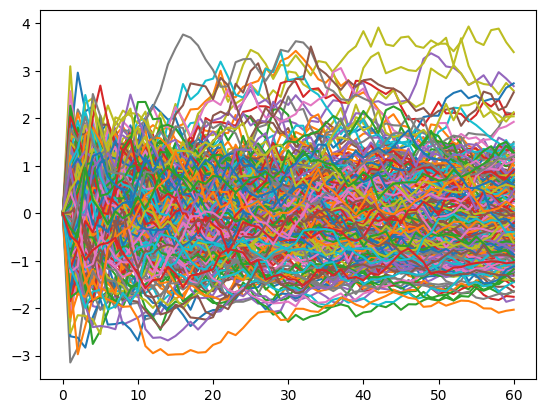

In [7]:
x, y = next(train_iter)


plt.plot(to_numpy(x)[:,:,0].T);



<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

In [18]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive

gauth = GoogleAuth(settings_file="../../CONFIG/settings.yaml")
gauth.LocalWebserverAuth()

drive = GoogleDrive(gauth)

c:\PHD_CVA_test\PHD_CVA\.venv\Lib\site-packages\oauth2client\_helpers.py:255: UserWarning: Cannot access ../../CONFIG/credentials.json: No such file or directory
  warnings.warn(_MISSING_FILE_MESSAGE.format(filename))


Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?client_id=603264849620-sasac0vcbh0lqpq399c7p46pr4c600f5.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8080%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive&access_type=offline&response_type=code&approval_prompt=force



ServerNotFoundError: Unable to find the server at oauth2.googleapis.com

In [15]:
from pathlib import Path

print(Path.cwd())

c:\PHD_CVA_test\PHD_CVA\NOTEBOOKS\PaperNotebooks


In [16]:
Path("../../CONFIG/settings.yaml")

WindowsPath('../../CONFIG/settings.yaml')